# Global weight Frobenius norm

Plot the overall `frobenius_norm` from one or more `weight_change.jsonl` files. Configure the `label` field in `RUNS` to control the figure legend.

In [22]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
# Each run needs a legend label and either:
# - path: a run directory, relative to the repo root or absolute
# - name: a run directory name under experiments/test
# - metrics_path: a direct path to a weight_change.jsonl file
RUNS = [
    {
        "label": "ES (30)",
        "path": Path("experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_20260315_212803"),
        "color": "C0",
    },
    {
        "label": "ES (30) + AWD ($\ell_1$)",
        "path": Path("experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l1wd0.01_20260320_201242"),
        "color": "C1",
    },
    {
        "label": "ES (30) + AWD ($\ell_2$)",
        "path": Path("experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize30_msFalse_l2wd10.0_20260421_151321"),
        "color": "C2",
    },
    {
        "label": "ES (128)",
        "path": Path("experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize128_msFalse_20260403_143926"),
        "color": "C3",
    },
    {
        "label": "ES (256)",
        "path": Path("experiments/test/Qwen2.5-3B-Instruct_countdown_seed0_popsize256_msFalse_20260427_033636"),
        "color": "C4",
    },
    {
        "label": "GRPO",
        "path": Path("grpo_experiments/runs/Qwen2.5-3B-Instruct_grpo_countdown_seed42"),
        "color": "black"
    },
]

EXPERIMENT_DIR = Path("experiments/test")
METRICS_FILENAME = "weight_change.jsonl"
METRIC_NAME = "frobenius_norm"

TITLE = "Global update norm over iterations"
X_LABEL = "Iteration"
Y_LABEL = "Update norm $||\\theta_t - \\theta_0||_2$"
LEGEND_TITLE = None

LINEWIDTH = 2.0
MARKERSIZE = 4.0
SHOW_MARKERS = True
LOG_Y = False
GRID_ALPHA = 0.3

SAVE_FIGURE = False
OUTPUT_PATH = Path("evaluation/weight_update_norm_comparison.pdf")


In [24]:
def find_repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "evaluation").is_dir() and (candidate / "es.py").is_file():
            return candidate
    raise RuntimeError("Run this notebook from the repo root or a directory inside the repo.")


REPO_ROOT = find_repo_root()


def resolve_path(path_like) -> Path:
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path.resolve()
    return (REPO_ROOT / path).resolve()


def resolve_run_spec(run_spec: dict) -> tuple[str, Path, Path]:
    if "metrics_path" in run_spec and run_spec["metrics_path"] is not None:
        metrics_path = resolve_path(run_spec["metrics_path"])
        run_dir = metrics_path.parent
    elif "path" in run_spec and run_spec["path"] is not None:
        run_dir = resolve_path(run_spec["path"])
        metrics_path = run_dir / METRICS_FILENAME
    elif "name" in run_spec and run_spec["name"]:
        run_dir = resolve_path(EXPERIMENT_DIR / run_spec["name"])
        metrics_path = run_dir / METRICS_FILENAME
    else:
        raise ValueError("Each run spec must define path, name, or metrics_path.")

    label = run_spec.get("label") or run_spec.get("name") or run_dir.name
    return str(label), run_dir, metrics_path


def load_jsonl(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text().splitlines() if line.strip()]


def load_run_frame(run_spec: dict) -> tuple[pd.DataFrame, dict]:
    label, run_dir, metrics_path = resolve_run_spec(run_spec)
    info = {
        "label": label,
        "run_dir": run_dir,
        "metrics_path": metrics_path,
        "available": metrics_path.is_file(),
        "records": 0,
        "min_step": None,
        "max_step": None,
        "final_value": None,
    }

    if not info["available"]:
        return pd.DataFrame(columns=["label", "step", METRIC_NAME]), info

    frame = pd.DataFrame(load_jsonl(metrics_path))
    required_columns = {"step", METRIC_NAME}
    missing_columns = required_columns - set(frame.columns)
    if missing_columns:
        raise ValueError(f"{metrics_path} is missing columns: {sorted(missing_columns)}")

    frame = frame[["step", METRIC_NAME]].copy()
    frame["label"] = label
    frame["run_dir"] = str(run_dir)
    frame["metrics_path"] = str(metrics_path)
    frame["step"] = pd.to_numeric(frame["step"], errors="coerce")
    frame[METRIC_NAME] = pd.to_numeric(frame[METRIC_NAME], errors="coerce")
    frame = frame.dropna(subset=["step", METRIC_NAME]).sort_values("step")
    frame = frame.drop_duplicates(subset=["step"], keep="last").reset_index(drop=True)

    info["records"] = len(frame)
    if len(frame):
        info["min_step"] = int(frame["step"].min())
        info["max_step"] = int(frame["step"].max())
        info["final_value"] = float(frame.iloc[-1][METRIC_NAME])

    return frame, info


frames = []
run_infos = []
for run_index, run_spec in enumerate(RUNS):
    frame, info = load_run_frame(run_spec)
    info["run_index"] = run_index
    frame["run_index"] = run_index
    frames.append(frame)
    run_infos.append(info)

metrics_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
summary_columns = [
    "run_index",
    "label",
    "run_dir",
    "metrics_path",
    "available",
    "records",
    "min_step",
    "max_step",
    "final_value",
]
summary_df = pd.DataFrame(run_infos, columns=summary_columns)
for column in ["run_dir", "metrics_path"]:
    if column in summary_df:
        summary_df[column] = summary_df[column].astype(str)

print(f"Repo root: {REPO_ROOT}")
display(summary_df)


Repo root: /home/kajetan/es_finetuning


,run_index,label,run_dir,metrics_path,available,records,min_step,max_step,final_value
0,0,ES (30),/home/kajetan/es_finetuning/experiments/test/Q...,/home/kajetan/es_finetuning/experiments/test/Q...,True,21,0,500,119.213889
1,1,ES (30) + AWD ($\ell_1$),/home/kajetan/es_finetuning/experiments/test/Q...,/home/kajetan/es_finetuning/experiments/test/Q...,True,21,0,500,92.133639
2,2,ES (30) + AWD ($\ell_2$),/home/kajetan/es_finetuning/experiments/test/Q...,/home/kajetan/es_finetuning/experiments/test/Q...,True,21,0,500,67.676355
3,3,ES (128),/home/kajetan/es_finetuning/experiments/test/Q...,/home/kajetan/es_finetuning/experiments/test/Q...,True,21,0,500,58.622030
4,4,ES (256),/home/kajetan/es_finetuning/experiments/test/Q...,/home/kajetan/es_finetuning/experiments/test/Q...,True,21,0,500,42.149415
5,5,GRPO,/home/kajetan/es_finetuning/grpo_experiments/r...,/home/kajetan/es_finetuning/grpo_experiments/r...,True,21,0,500,1.324287


/tmp/ipykernel_617071/3558987375.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


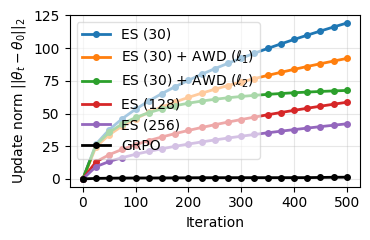

In [25]:
fig, ax = plt.subplots(figsize=(3.8, 2.5), constrained_layout=True)


if metrics_df.empty:
    ax.text(
        0.5,
        0.5,
        "No Frobenius-norm metrics found",
        ha="center",
        va="center",
        transform=ax.transAxes,
        color="0.4",
    )
else:
    for _, group in metrics_df.groupby("run_index", sort=False):
        label = group["label"].iloc[0]
        linestyle = RUNS[group["run_index"].iloc[0]].get("linestyle", "-")
        color = RUNS[group["run_index"].iloc[0]].get("color", None)
        marker = RUNS[group["run_index"].iloc[0]].get("marker", "o") if SHOW_MARKERS else None
        ax.plot(
            group["step"],
            group[METRIC_NAME],
            marker=marker,
            markersize=MARKERSIZE,
            linewidth=LINEWIDTH,
            label=label,
            linestyle=linestyle,
            color=color,
        )

    ax.legend(title=LEGEND_TITLE, framealpha=0.6)

# ax.set_title(TITLE)
ax.set_xlabel(X_LABEL)
ax.set_ylabel(Y_LABEL)
ax.grid(alpha=GRID_ALPHA)
if LOG_Y:
    ax.set_yscale("log")

if SAVE_FIGURE:
    output_path = resolve_path(OUTPUT_PATH)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")

plt.tight_layout()
plt.savefig("weight_update_norm_comparison.pdf", bbox_inches="tight")
plt.show()
